In [1]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt



import keras
from keras import losses
from keras.models import Sequential  
from keras.layers import Dense
from keras.optimizers import SGD
from keras import metrics

2026-06-11 16:54:27.553291: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Create data:

/tmp/ipykernel_91765/887030381.py:21: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  x1 = data[:,0].astype(np.float)
/tmp/ipykernel_91765/887030381.py:22: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  x2 = data[:,1].astype(np.float)
/tmp/ipykernel_91765/887030381.py:23: DeprecationWarning: `np.float` is a deprecated alias for the builtin `

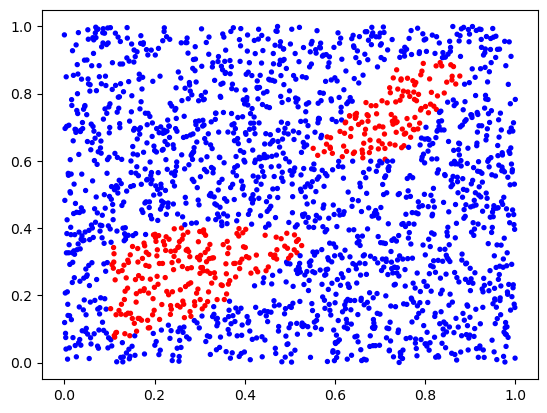

In [2]:
def create_data(N):
    x1 = np.linspace(0.0, 1.0, num=N)
    x2 = random.rand(N)
    sigma = 0.02
    offset = 0.2
    w = 1
    y = np.zeros(N)
    color = []
    for i in range(N):
        color.append("blue")        
        if x1[i]>0.1 and x2[i]<0.9:
            if np.square(x2[i]-(w*np.square(x1[i])+offset)) < sigma:
                if  x2[i]<0.4 or x2[i]>0.6:
                    y[i]=1
                    color[i]="red"
    out = np.column_stack([x1,x2,y,color])
    return out

data=create_data(2000)
#print(color)
x1 = data[:,0].astype(np.float)
x2 = data[:,1].astype(np.float)
y = data[:,2].astype(np.float)
color = data[:,3]
plt.scatter(x1,x2,s=8,color=color)
plt.show()

Prepare data:

In [3]:
x_train = np.column_stack([x1,x2])
y_train = y

Create the model:

In [12]:
initializer = keras.initializers.RandomNormal(mean=0., stddev=1.)

model = Sequential()
model.add(Dense(5, activation='sigmoid', input_dim=2, kernel_initializer=initializer, 
                bias_initializer=initializer))
model.add(Dense(1, activation='sigmoid', kernel_initializer=initializer,
               bias_initializer=initializer))


sgd = keras.optimizers.SGD(lr=0.8)


model.compile(loss = 'mean_squared_error',  
   optimizer = sgd, metrics = 'accuracy')


model.fit(x_train, y_train, batch_size = 32, epochs = 1000,
          validation_split=0, verbose=1)

Epoch 1/1000
63/63 [==============================] - 0s 1ms/step - loss: 0.1423 - accuracy: 0.8355
Epoch 2/1000
63/63 [==============================] - 0s 1ms/step - loss: 0.1383 - accuracy: 0.8355
Epoch 3/1000
63/63 [==============================] - 0s 1ms/step - loss: 0.1382 - accuracy: 0.8355
Epoch 4/1000
63/63 [==============================] - 0s 1ms/step - loss: 0.1381 - accuracy: 0.8355
Epoch 5/1000
63/63 [==============================] - 0s 1ms/step - loss: 0.1381 - accuracy: 0.8355
Epoch 6/1000
63/63 [==============================] - 0s 1ms/step - loss: 0.1381 - accuracy: 0.8355
Epoch 7/1000
63/63 [==============================] - 0s 870us/step - loss: 0.1380 - accuracy: 0.8355
Epoch 8/1000
63/63 [==============================] - 0s 1ms/step - loss: 0.1379 - accuracy: 0.8355
Epoch 9/1000
63/63 [==============================] - 0s 1ms/step - loss: 0.1377 - accuracy: 0.8355
Epoch 10/1000
63/63 [==============================] - 0s 1ms/step - loss: 0.1377 - accuracy: 0.83

Create test data:

 131/3125 [>.............................] - ETA: 2s

/tmp/ipykernel_91765/2624632526.py:3: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  x1_test = test_data[:,0].astype(np.float)
/tmp/ipykernel_91765/2624632526.py:4: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  x2_test = test_data[:,1].astype(np.float)


3125/3125 [==============================] - 2s 756us/step


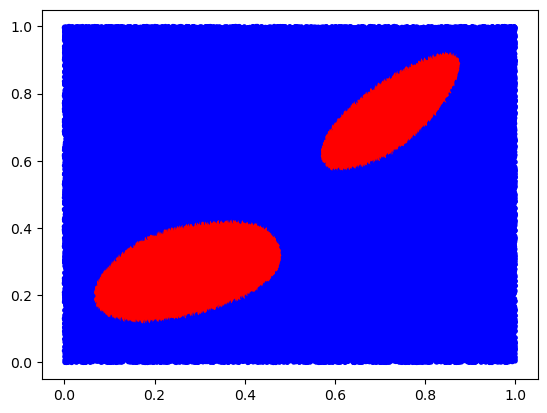

In [13]:
N = 100000
test_data=create_data(N)
x1_test = test_data[:,0].astype(np.float)
x2_test = test_data[:,1].astype(np.float)

x_test = np.column_stack([x1_test,x2_test])
#print(x_test)

pred = model.predict(x_test) 
#print(pred)

color = []
for i in range(N):
    color.append("blue")
    if pred[i]>=0.5:
        color[i]="red"
            
plt.scatter(x1_test,x2_test,s=8,color=color)
plt.show()            